# Modelo PointNet

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install lazrs laszip laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 649.3/649.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 8.0 MB/s eta 0:00:00


In [ ]:
import os
import laspy
import numpy as np
import pandas as pd
from skimage.transform import resize

In [ ]:
laz_files = sorted([
    f for f in os.listdir("/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR")
    if f.endswith(".laz")
])

print(laz_files)

['SaoManuelTotal_001.laz', 'SaoManuelTotal_002.laz', 'SaoManuelTotal_004.laz', 'SaoManuelTotal_005.laz', 'SaoManuelTotal_006.laz', 'SaoManuelTotal_007.laz']


In [ ]:
X_points = []
y_dap = []
parcelas_ids = []
talhoes_ids = []

In [ ]:
import geopandas as gpd

gdf = gpd.read_file(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/shapes/Parcelas/parcelas.shp"
)

gdf["talhao"] = (
    gdf["talhao"]
    .astype(str)
    .str.zfill(3)
)

gdf["parcela"] = (
    gdf["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(gdf.head())

print(gdf["talhao"].unique())

   id     elev parcela talhao     Fazenda        Especie Mat_gen  \
0   1  738.637     001    001  São Manuel  Eucalyptus sp    I144   
1   2  739.195     002    001  São Manuel  Eucalyptus sp    I144   
2   3  774.722     003    003  São Manuel           None    None   
3   4  781.896     004    004  São Manuel  Eucalyptus sp    None   
4   5  776.755     005    004  São Manuel  Eucalyptus sp    None   

                                   geometry  
0  POINT Z (749049.463 7480009.299 738.637)  
1   POINT Z (748983.36 7480013.776 739.195)  
2  POINT Z (748849.993 7479561.952 774.722)  
3  POINT Z (748836.068 7479441.914 781.896)  
4  POINT Z (748827.399 7479324.807 776.755)  
['001' '003' '004' '002' '005' '008' '006' '007']


In [ ]:
def sample_points(points, n_points=2048, seed=42):
    rng = np.random.default_rng(seed)
    if len(points) >= n_points:
        idx = rng.choice(
            len(points),
            n_points,
            replace=False
        )
    else:
        idx = rng.choice(
            len(points),
            n_points,
            replace=True
        )
    return points[idx]

In [ ]:
def normalize_points(points):
    centroid = np.mean(points, axis=0)
    points = points - centroid

    max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
    points = points / max_dist

    return points

In [ ]:
# Criamos essa função para gerar um ruido gaussiano de 30cm em Z - a ideia é causar dificuldade pro modelo predizer
def add_height_noise(points, sigma=0.30):

    noisy = points.copy()

    noisy[:,2] += np.random.normal(
        0,
        sigma,
        len(points)
    )

    return noisy

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/SaoManuelTotal_08022025_plot_metric.csv"
)

df["parcela"] = (
    df["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(df[["parcela", "D_cm"]].head())

  parcela  D_cm
0     001  17.6
1     002  16.8
2     004  12.9
3     005  13.8
4     006  13.8


In [ ]:
X_points = []

y_dap = []

for laz_file in laz_files:
    print("Processando dados LiDAR:", laz_file)

    talhao = laz_file.split("_")[-1].replace(".laz","")

    las_path = os.path.join(
        "/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR",
        laz_file
    )

    las = laspy.read(las_path)

    x_lidar = np.array(las.x)
    y_lidar = np.array(las.y)
    z_lidar = np.array(las.z)

    points_all = np.vstack(
        (x_lidar, y_lidar, z_lidar)
    ).transpose()

    gdf_talhao = gdf[
        gdf["talhao"] == talhao
    ]

    print("Parcelas:", len(gdf_talhao))

    for idx, row in gdf_talhao.iterrows():

        geom = row.geometry

        cx = geom.x
        cy = geom.y

        radius = 11.28

        dist = np.sqrt(
            (x_lidar - cx)**2 +
            (y_lidar - cy)**2
        )

        mask = dist <= radius

        crop = points_all[mask]

        if len(crop) < 500:
            continue

        crop = sample_points(
            crop,
            n_points=2048,
            seed=42
        )

        crop = add_height_noise(
            crop,
            sigma=0.30
        )

        crop = normalize_points(crop)

        parcela = str(
            row["parcela"]
        ).zfill(3)

        dap_row = df[
            df["parcela"] == parcela
        ]

        if len(dap_row) == 0:
            continue

        dap = dap_row["D_cm"].values[0]

        X_points.append(crop)

        y_dap.append(dap)

        print(
            f"Parcela {parcela}"
            f" - pontos {crop.shape}"
            f" DAP = {dap}"
        )

Processando dados LiDAR: SaoManuelTotal_001.laz
Parcelas: 2
Parcela 001 - pontos (2048, 3) DAP = 17.6
Parcela 002 - pontos (2048, 3) DAP = 16.8
Processando dados LiDAR: SaoManuelTotal_002.laz
Parcelas: 2
Parcela 006 - pontos (2048, 3) DAP = 13.8
Parcela 007 - pontos (2048, 3) DAP = 16.0
Processando dados LiDAR: SaoManuelTotal_004.laz
Parcelas: 2
Parcela 004 - pontos (2048, 3) DAP = 12.9
Parcela 005 - pontos (2048, 3) DAP = 13.8
Processando dados LiDAR: SaoManuelTotal_005.laz
Parcelas: 2
Parcela 008 - pontos (2048, 3) DAP = 17.6
Parcela 009 - pontos (2048, 3) DAP = 16.7
Processando dados LiDAR: SaoManuelTotal_006.laz
Parcelas: 3
Parcela 010 - pontos (2048, 3) DAP = 17.8
Parcela 011 - pontos (2048, 3) DAP = 17.0
Parcela 012 - pontos (2048, 3) DAP = 17.4
Processando dados LiDAR: SaoManuelTotal_007.laz
Parcelas: 2
Parcela 013 - pontos (2048, 3) DAP = 17.4
Parcela 014 - pontos (2048, 3) DAP = 20.4


In [ ]:
X_points = np.array(X_points)

y_dap = np.array(y_dap)

print(X_points.shape)

print(y_dap.shape)

(13, 2048, 3)
(13,)


In [ ]:
X_points = np.array(X_points)
y_dap = np.array(y_dap)

In [ ]:
print(X_points.shape)
print(y_dap.shape)

(13, 2048, 3)
(13,)


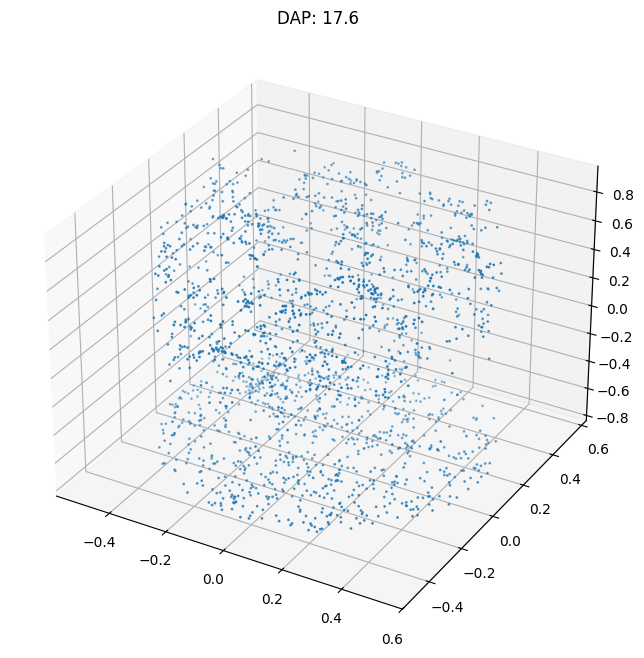

In [ ]:
import matplotlib.pyplot as plt

sample = X_points[0]

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    sample[:,0],
    sample[:,1],
    sample[:,2],
    s=1
)

plt.title(
    f"DAP: {y_dap[0]}"
)

plt.show()

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    kf.split(X_points)
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        self.mlp1 = nn.Conv1d(3,64,1)
        self.mlp2 = nn.Conv1d(64,128,1)
        self.mlp3 = nn.Conv1d(128,256,1)

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,1)

        self.dropout = nn.Dropout(0.3)

    def forward(self,x):

        x = x.transpose(1,2)

        x = F.relu(self.mlp1(x))
        x = F.relu(self.mlp2(x))
        x = F.relu(self.mlp3(x))

        x = torch.max(x,dim=2)[0]

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [ ]:
import time
import psutil
import os
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import matplotlib.pyplot as plt

In [ ]:
results = []
all_targets = []
all_predictions = []
all_fold_ids = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(folds):

    print("\n")
    print(f"FOLD {fold+1}")

    X_train = X_points[train_idx]
    X_test = X_points[test_idx]

    y_train = y_dap[train_idx]
    y_test = y_dap[test_idx]

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).view(-1,1)

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    ).view(-1,1)

    train_dataset = TensorDataset(
        X_train,
        y_train
    )

    test_dataset = TensorDataset(
        X_test,
        y_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=2,
        shuffle=False
    )

    model = PointNetRegressor()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    start_train = time.time()
    train_losses = []
    num_epochs = 50

    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0

        for points, targets in train_loader:

            optimizer.zero_grad()
            outputs = model(points)
            loss = criterion(
                outputs,
                targets
            )
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = (
            epoch_loss /
            len(train_loader)
        )
        train_losses.append(avg_loss)

    end_train = time.time()
    training_time = (end_train - start_train)

    predictions = []
    targets = []
    start_inf = time.time()
    model.eval()

    with torch.no_grad():

        for points, labels in test_loader:

            outputs = model(points)
            predictions.extend(
                outputs.numpy().flatten()
            )
            targets.extend(
                labels.numpy().flatten()
            )

    end_inf = time.time()
    total_inf_time = (end_inf - start_inf)
    latency = (total_inf_time / len(test_dataset))
    throughput = (len(test_dataset) / total_inf_time)
    fps = 1 / latency
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    mape = np.mean(np.abs((np.array(targets) - np.array(predictions)) / np.array(targets))) * 100
    bias = np.mean(np.array(predictions) - np.array(targets))
    rrmse = (rmse / np.mean(targets)) * 100
    process = psutil.Process(os.getpid())
    memory_mb = (process.memory_info().rss / 1024**2)
    total_params = sum(p.numel() for p in model.parameters())
    all_targets.extend(targets)
    all_predictions.extend(predictions)
    all_fold_ids.extend([fold+1] * len(targets))

    results.append({

        "fold": fold+1,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "bias": bias,
        "rrmse": rrmse,
        "latency": latency,
        "throughput": throughput,
        "fps": fps,
        "memory_mb": memory_mb,
        "params": total_params,
        "training_time": training_time

    })

    print(
        f"MAE={mae:.3f} "
        f"RMSE={rmse:.3f}"
    )



FOLD 1
MAE=0.519 RMSE=0.558


FOLD 2
MAE=2.059 RMSE=2.343


FOLD 3
MAE=2.521 RMSE=2.958


FOLD 4
MAE=0.492 RMSE=0.605


FOLD 5
MAE=1.813 RMSE=1.818


In [ ]:
results_df = pd.DataFrame(results)

display(results_df)

,fold,mae,rmse,mape,bias,rrmse,latency,throughput,fps,memory_mb,params,training_time
0,1,0.518534,0.557564,2.999279,-0.518534,3.216716,0.007914,126.366176,126.366176,1384.750000,82817,9.843718
1,2,2.059289,2.343484,14.650271,1.725077,15.485575,0.007756,128.928563,128.928563,1384.750000,82817,7.809235
2,3,2.521345,2.957972,16.147686,0.050203,17.712407,0.005070,197.239784,197.239784,1384.750000,82817,9.316204
3,4,0.492147,0.605122,2.845304,-0.352085,3.549105,0.007274,137.473091,137.473091,1384.757812,82817,10.063256
4,5,1.813225,1.818199,10.855719,0.134399,10.822616,0.005202,192.249347,192.249347,1384.757812,82817,9.731546


In [ ]:
summary = pd.DataFrame({

    "Media":
        results_df.mean(
            numeric_only=True
        ),

    "Std":
        results_df.std(
            numeric_only=True
        )
})

display(summary)

,Media,Std
fold,3.000000,1.581139
mae,1.480908,0.926186
rmse,1.656468,1.061247
mape,9.499652,6.306729
bias,0.207812,0.890700
rrmse,10.157284,6.666198
latency,0.006643,0.001397
throughput,156.451392,35.241980
fps,156.451392,35.241980
memory_mb,1384.753125,0.004279


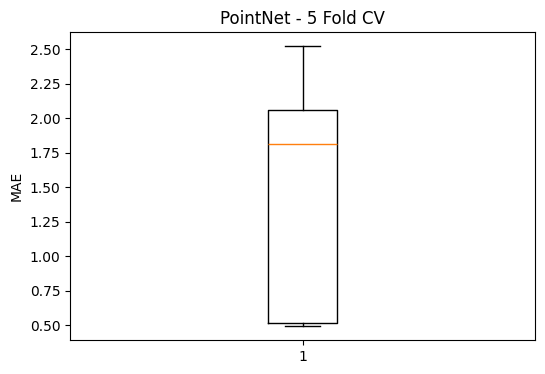

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(results_df["mae"])
plt.ylabel("MAE")
plt.title("PointNet - 5 Fold CV")
plt.show()

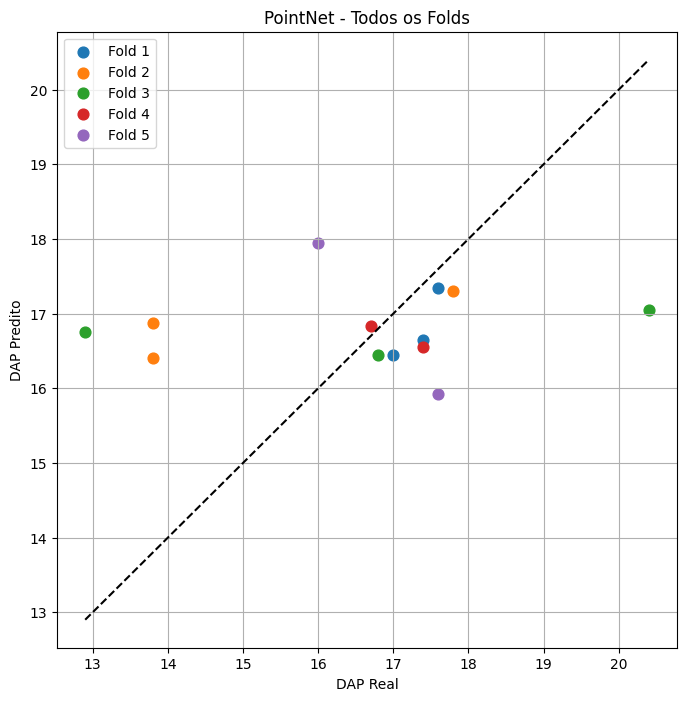

In [ ]:
plt.figure(figsize=(8,8))

for fold_id in sorted(set(all_fold_ids)):

    idx = (
        np.array(all_fold_ids)
        ==
        fold_id
    )

    plt.scatter(
        np.array(all_targets)[idx],
        np.array(all_predictions)[idx],
        s=60,
        label=f"Fold {fold_id}"
    )

mn = min(all_targets)
mx = max(all_targets)

plt.plot(
    [mn,mx],
    [mn,mx],
    'k--'
)

plt.xlabel("DAP Real")
plt.ylabel("DAP Predito")
plt.title("PointNet - Todos os Folds")
plt.legend()
plt.grid()
plt.show()

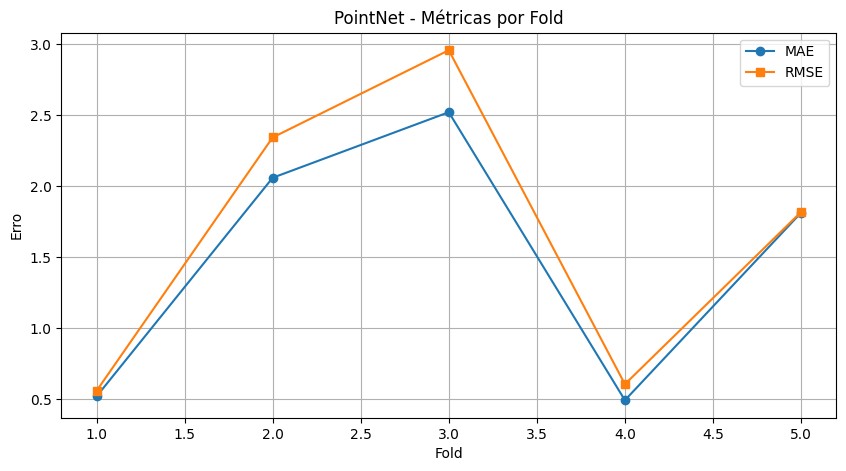

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    results_df["fold"],
    results_df["mae"],
    marker="o",
    label="MAE"
)

plt.plot(
    results_df["fold"],
    results_df["rmse"],
    marker="s",
    label="RMSE"
)

plt.xlabel("Fold")
plt.ylabel("Erro")
plt.title("PointNet - Métricas por Fold")

plt.legend()
plt.grid()
plt.show()

In [ ]:
import json
import paho.mqtt.client as mqtt

MQTT_HOST = "andromeda.lasdpc.icmc.usp.br"
MQTT_PORT = 5163
MQTT_TOPIC = "grupo3/modelos/metricas"

modelo_ia = "PointNet"
cenario = "Cenario 2"

dados = {
    "modelo_ia": modelo_ia,
    "cenario": cenario,
    "mae": float(summary.loc["mae", "Media"]),
    "mape": float(summary.loc["mape", "Media"]),
    "rrmse": float(summary.loc["rrmse", "Media"]),
    "bias": float(summary.loc["bias", "Media"]),
    "tempo_inferencia": float(summary.loc["latency", "Media"]),
    "throughput": float(summary.loc["throughput", "Media"])
}

client = mqtt.Client(
    mqtt.CallbackAPIVersion.VERSION2,
    transport="websockets"
)

client.ws_set_options(path="/mqtt")
client.connect(MQTT_HOST, MQTT_PORT, 60)
client.publish(MQTT_TOPIC, json.dumps(dados))
client.disconnect()

print("Mensagem MQTT enviada pela porta 5163 via WebSocket.")
print(dados)